HW3 - Corentin Venet Maxime Lacroix

In [ ]:
#Importing library

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [3]:
df = pd.read_excel('PM.xlsx')

df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

# Convert from YYYYMM format to proper datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y%m')

df.set_index('Date', inplace=True)

df.head()


/Users/maximelacroix/Library/Python/3.13/lib/python/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,PM1,PM2
Date,,
2005-01-01,-7.605484,0.195763
2005-02-01,0.933716,1.696970
2005-03-01,-5.480934,-1.181779
2005-04-01,-7.028594,-0.683404
2005-05-01,8.406572,3.465246


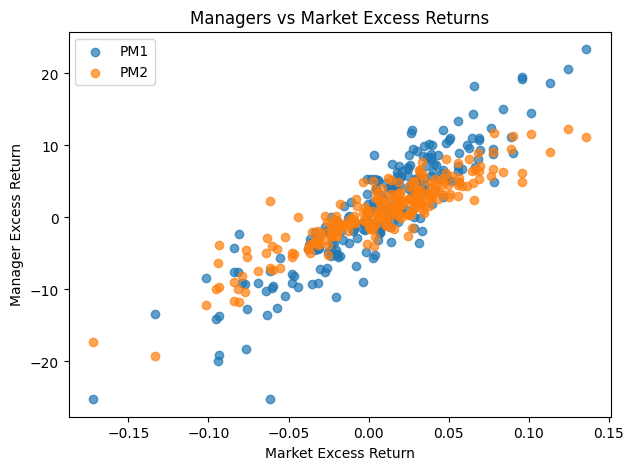

/var/folders/lb/2vc7k14s3db649zm9644tb2c0000gn/T/ipykernel_5405/951884493.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data['PM1_excess'], data['PM2_excess']], labels=['PM1','PM2'])


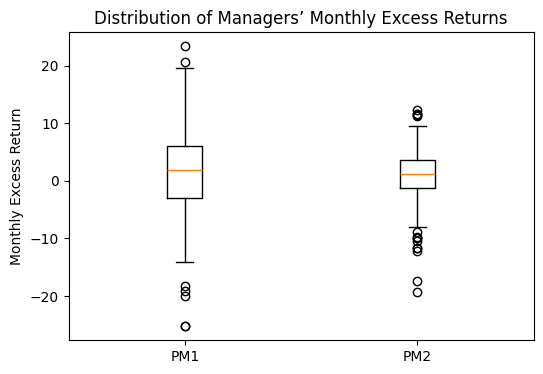

In [4]:
ff = pd.read_csv('F-F_Research_Data_Factors.CSV', skiprows=3)
ff = ff.rename(columns={'Unnamed: 0': 'Date'})

ff = ff[ff['Date'].astype(str).str.match(r'^\d{6}$')]

ff['Date'] = pd.to_datetime(ff['Date'], format='%Y%m')
ff.set_index('Date', inplace=True)

ff = ff.apply(pd.to_numeric, errors='coerce') / 100

Mkt = ff['Mkt-RF']
Rf  = ff['RF']

data = df.join(ff[['Mkt-RF','SMB','HML','RF']], how='inner')

data['PM1_excess'] = data['PM1'] - data['RF']
data['PM2_excess'] = data['PM2'] - data['RF']

plt.figure(figsize=(7,5))
plt.scatter(data['Mkt-RF'], data['PM1_excess'], label='PM1', alpha=0.7)
plt.scatter(data['Mkt-RF'], data['PM2_excess'], label='PM2', alpha=0.7)
plt.xlabel('Market Excess Return')
plt.ylabel('Manager Excess Return')
plt.title('Managers vs Market Excess Returns')
plt.legend()
plt.show()


plt.figure(figsize=(6,4))
plt.boxplot([data['PM1_excess'], data['PM2_excess']], labels=['PM1','PM2'])
plt.ylabel('Monthly Excess Return')
plt.title('Distribution of Managers’ Monthly Excess Returns')
plt.show()


In [5]:
def performance_stats(excess_ret, benchmark):
    mean = excess_ret.mean()
    std = excess_ret.std()
    sharpe = mean / std

    # Information ratio: relative to benchmark (market)
    active_return = excess_ret - benchmark
    info_ratio = active_return.mean() / active_return.std()

    # Maximum drawdown
    cum_ret = (1 + excess_ret).cumprod()
    running_max = cum_ret.cummax()
    drawdown = (cum_ret - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'Mean': mean,
        'Std': std,
        'Sharpe': sharpe,
        'Info Ratio': info_ratio,
        'Max Drawdown': max_dd
    }

stats_PM1 = performance_stats(data['PM1_excess'], Mkt)
stats_PM2 = performance_stats(data['PM2_excess'], Mkt)

summary = pd.DataFrame([stats_PM1, stats_PM2], index=['PM1', 'PM2'])
print(summary)


         Mean       Std    Sharpe  Info Ratio  Max Drawdown
PM1  1.372505  7.575846  0.181169    0.181059 -3.833747e+08
PM2  0.867001  4.663533  0.185911    0.185796 -4.304142e+04


Given the boxplot from question (3.a), PM2 seems to be more stable (lower volatility) compared to PM1 given the interquartile range with a center around 0. When looking at the first plot, we can see that their returns are strongly correlated with the market's suggesting no clear indication of alpha.

In [6]:
def fama_french_regression(excess_ret, factors):
    X = sm.add_constant(factors)         
    model = sm.OLS(excess_ret, X).fit()
    return model

factors = data[['Mkt-RF', 'SMB', 'HML']]

ff3_PM1 = fama_french_regression(data['PM1_excess'], factors)

print(ff3_PM1.summary())


                            OLS Regression Results                            
Dep. Variable:             PM1_excess   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 1.276e+04
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          9.89e-261
Time:                        16:18:48   Log-Likelihood:                -214.66
No. Observations:                 240   AIC:                             437.3
Df Residuals:                     236   BIC:                             451.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1747      0.039      4.444      0.0

In [7]:
ff3_PM2 = fama_french_regression(data['PM2_excess'], factors)
print(ff3_PM2.summary())

                            OLS Regression Results                            
Dep. Variable:             PM2_excess   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     2662.
Date:                Mon, 13 Oct 2025   Prob (F-statistic):          1.34e-181
Time:                        16:18:49   Log-Likelihood:                -283.52
No. Observations:                 240   AIC:                             575.0
Df Residuals:                     236   BIC:                             589.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1866      0.052      3.563      0.0

Looking at the constant, PM2 has a higher alpha with a lower beta but its HML loadings are higher indicating a more conservative trading strategy giving more stable returns.

In [20]:
X = sm.add_constant(data[['Mkt-RF','SMB','HML']])
lag = 6  # HAC lag for Newey–West SEs

m1 = sm.OLS(data['PM1_excess'], X).fit(cov_type='HAC', cov_kwds={'maxlags': lag})
m2 = sm.OLS(data['PM2_excess'], X).fit(cov_type='HAC', cov_kwds={'maxlags': lag})

a1, s1, t1 = m1.params['const'], m1.bse['const'], m1.tvalues['const']
a2, s2, t2 = m2.params['const'], m2.bse['const'], m2.tvalues['const']
print(f"PM1 α={a1:.4f} (t={t1:.2f}), PM2 α={a2:.4f} (t={t2:.2f})")


t_diff = (a1 - a2) / np.sqrt(s1**2 + s2**2)
p_diff = 2 * (1 - stats.t.cdf(abs(t_diff), df=len(data)))
print(f"Alpha diff test: t={t_diff:.2f}, p={p_diff:.3f}")


def sharpe(r): return r.mean() / r.std(ddof=1)
r1, r2 = data['PM1_excess'], data['PM2_excess']
sr1, sr2 = sharpe(r1), sharpe(r2)
rho = np.corrcoef(r1, r2)[0,1]; n = len(r1)
z_sr = (sr1 - sr2) / np.sqrt((1 - 0.5*sr1**2 - 0.5*sr2**2 + rho*sr1*sr2)/(n-1))
p_sr = 2 * (1 - stats.norm.cdf(abs(z_sr)))
print(f"Sharpe PM1={sr1:.3f}, PM2={sr2:.3f} → z={z_sr:.2f}, p={p_sr:.3f}")


ir1, ir2 = a1/m1.resid.std(ddof=1), a2/m2.resid.std(ddof=1)
print(f"Info Ratio PM1={ir1:.3f}, PM2={ir2:.3f}")


PM1 α=0.1747 (t=4.01), PM2 α=0.1866 (t=3.47)
Alpha diff test: t=-0.17, p=0.863
Sharpe PM1=0.181, PM2=0.186 → z=-0.07, p=0.941
Info Ratio PM1=0.294, PM2=0.236


Summary:
- Both show positive α (beat market). PM2 has higher α (p=0.863).
- PM2 has higher Sharpe (p=0.941).
- PM1 has higher Information Ratio.

------------

In [ ]:
pead = pd.read_csv('pead.csv')
pead['date'] = pd.to_datetime(pead['date'])
pead.dropna()
pead.head()

,permno,date,mktcap,ret,mkt,gvkey,ann
0,10104,2010-12-31,158140746.0,0.000320,-0.00099,12142.0,0
1,10104,2011-01-03,159757520.4,0.010224,0.01180,12142.0,0
2,10104,2011-01-04,159050181.6,-0.004428,-0.00260,12142.0,0
3,10104,2011-01-05,156827116.8,-0.013977,0.00590,12142.0,0
4,10104,2011-01-06,157483931.4,0.004188,-0.00150,12142.0,0


Null hypothesis : Stocks with the most positive (or negative) standardized excess returns on the day after annoucement do not have a different average returns in the next 30 days

     k     pos     neg    diff       t       p
0  2.0  0.0005  0.0003  0.0002  2.3060  0.0211
1  2.5  0.0005  0.0003  0.0002  1.9524  0.0509
2  3.0  0.0005  0.0002  0.0003  1.7553  0.0792
3  3.5  0.0004  0.0003  0.0001  1.2245  0.2208
4  4.0  0.0004  0.0002  0.0002  1.4191  0.1559


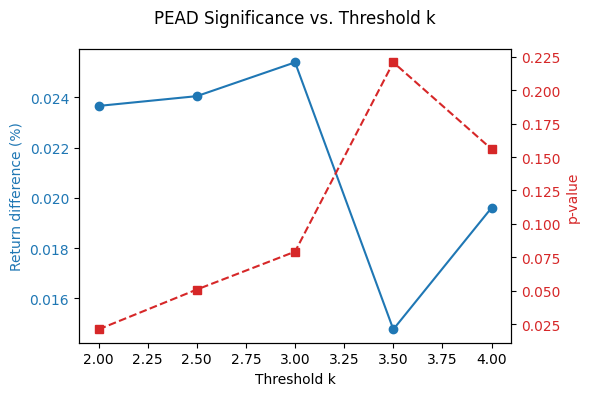

In [ ]:
# Compute standardized excess return
pead['excess'] = pead['ret'] - pead['mkt']
pead['sigma'] = pead.groupby('permno')['excess'].rolling(60).std().reset_index(level=0, drop=True)
pead['s'] = pead['excess'] / pead['sigma']
# After computing sigma
pead = pead.dropna(subset=['sigma', 'excess', 'ret', 'mkt']) 

# Announcement days only
ann_days = pead[pead['ann'] == 1].copy()

# Function to compute average 30-day return
def next30d_avg(x):
    firm, day = x['permno'], x['date']
    mask = (pead['permno'] == firm) & (pead['date'] > day) & (pead['date'] <= day + pd.Timedelta(days=30))
    return pead.loc[mask, 'ret'].mean()

# Sweep thresholds
results = []
for k in [2, 2.5, 3, 3.5, 4]:
    pos = ann_days[ann_days['s'] > k].copy()
    neg = ann_days[ann_days['s'] < -k].copy()
    pos['ret_30d'] = pos.apply(next30d_avg, axis=1)
    neg['ret_30d'] = neg.apply(next30d_avg, axis=1)
    
    mean_pos, mean_neg = pos['ret_30d'].mean(), neg['ret_30d'].mean()
    t, p = stats.ttest_ind(pos['ret_30d'].dropna(), neg['ret_30d'].dropna(), equal_var=False)
    results.append({'k': k, 'pos': mean_pos, 'neg': mean_neg, 'diff': mean_pos - mean_neg, 't': t, 'p': p})

# Convert to DataFrame
res = pd.DataFrame(results)
print(res.round(4))

# Plot drift magnitude vs. k
fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(res['k'], res['diff']*100, 'o-', label='Mean return difference (pos - neg, %)')
ax1.set_xlabel('Threshold k')
ax1.set_ylabel('Return difference (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(res['k'], res['p'], 's--', color='tab:red', label='p-value')
ax2.set_ylabel('p-value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle('PEAD Significance vs. Threshold k', fontsize=12)
fig.tight_layout()
plt.show()


For almost all values of k, p > 0.05 so we cannot reject the null hypothesis


PEAD results by period:
      Period  Mean_Pos  Mean_Neg    Diff       t       p
0  2011–2015    0.0006    0.0006  0.0000  0.2559  0.7981
1  2016–2020    0.0004    0.0002  0.0002  1.0437  0.2967
2  2021–2024    0.0011    0.0003  0.0008  1.6321  0.1029


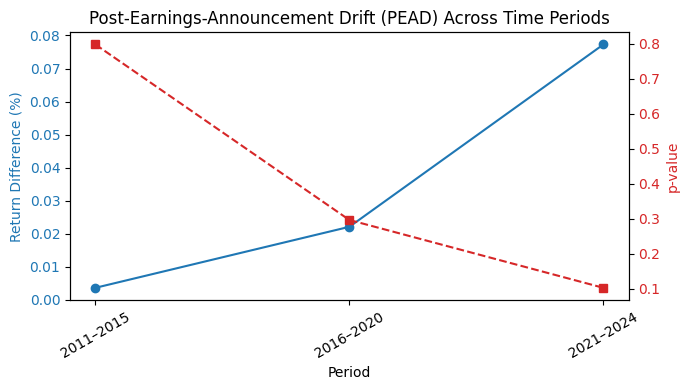

In [44]:
pead['date'] = pd.to_datetime(pead['date'])

pead['excess'] = pead['ret'] - pead['mkt']
pead['sigma'] = (
    pead.groupby('permno')['excess']
    .rolling(60)
    .std()
    .reset_index(level=0, drop=True)
)
pead['s'] = pead['excess'] / pead['sigma']
pead = pead.dropna(subset=['s', 'excess', 'sigma', 'ret'])

periods = [
    ('2011–2015', ('2011-01-01', '2015-12-31')),
    ('2016–2020', ('2016-01-01', '2020-12-31')),
    ('2021–2024', ('2021-01-01', '2024-12-31')),
]

def compute_avg_30d_return(row):
    firm, day = row['permno'], row['date']
    mask = (
        (pead['permno'] == firm)
        & (pead['date'] > day)
        & (pead['date'] <= day + pd.Timedelta(days=30))
    )
    vals = pead.loc[mask, 'ret'].values
    if len(vals) == 0:
        return np.nan
    else:
        return float(np.nanmean(vals))

k = 3 #Checking for other values of k takes too long to compute and don't change the results significantly
results = []

for label, (start, end) in periods:
    df_sub = pead[(pead['date'] >= start) & (pead['date'] <= end) & (pead['ann'] == 1)].copy()
    pos = df_sub[df_sub['s'] > k].copy()
    neg = df_sub[df_sub['s'] < -k].copy()

    pos_30d = [compute_avg_30d_return(x) for _, x in pos.iterrows()]
    neg_30d = [compute_avg_30d_return(x) for _, x in neg.iterrows()]
    pos['ret_30d'] = pd.Series(pos_30d, index=pos.index)
    neg['ret_30d'] = pd.Series(neg_30d, index=neg.index)

    pos = pos.dropna(subset=['ret_30d'])
    neg = neg.dropna(subset=['ret_30d'])

    mean_pos = pos['ret_30d'].mean()
    mean_neg = neg['ret_30d'].mean()
    diff = mean_pos - mean_neg
    t, p = stats.ttest_ind(pos['ret_30d'], neg['ret_30d'], equal_var=False)

    results.append({
        'Period': label,
        'Mean_Pos': mean_pos,
        'Mean_Neg': mean_neg,
        'Diff': diff,
        't': t,
        'p': p
    })

res = pd.DataFrame(results)
print("\nPEAD results by period:")
print(res.round(4))

#Plotting results to see the difference
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(res['Period'], res['Diff'] * 100, 'o-', color='tab:blue', label='Return Diff (Pos–Neg, %)')
ax1.set_xlabel('Period')
ax1.set_ylabel('Return Difference (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.xticks(rotation=30)

ax2 = ax1.twinx()
ax2.plot(res['Period'], res['p'], 's--', color='tab:red', label='p-value')
ax2.set_ylabel('p-value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Post-Earnings-Announcement Drift (PEAD) Across Time Periods')
fig.tight_layout()
plt.show()


The p-value drops, which means the results are becoming more significant over time however p_value > 0.05 so we cannot reject the null hypothesis. So based on the empirical data, there is no evidence that these have weaken even though they are fairly low.